In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from src.evaluate import calculate_metrics, plot_predictions
from src.models.baselines import train_linear_regression, train_random_forest, train_predict_arima
from src.models.advanced import build_and_train_lstm

Load dữ liệu và Chia tập Train/Test theo thời gian

In [2]:
df = pd.read_csv('../data/processed/featured_data.csv', index_col='Datetime', parse_dates=True)

target_col = 'CO(GT)'
# X =df[target_col]
X = df.drop(columns=[target_col])
y = df[target_col]

display(X.head())
display(y.head())

split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_dates = y_test.index

print(f"Tập Train: {X_train.shape}, Tập Test: {X_test.shape}")

,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,T_lag_1,T_lag_2,T_lag_3,RH_lag_1,RH_lag_2,RH_lag_3,CO(GT)_rolling_mean_6,PT08.S1(CO)_rolling_mean_6,T_rolling_mean_6,RH_rolling_mean_6
Datetime,,,,,,,,,,,,,,,,,,,,,
2004-11-03 00:00:00,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,...,11.2,11.2,11.0,59.2,59.6,60.0,1.966667,1316.500000,12.033333,54.900000
2004-11-03 01:00:00,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,...,11.3,11.2,11.2,56.8,59.2,59.6,1.733333,1287.333333,11.650000,56.216667
2004-11-03 02:00:00,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,...,10.7,11.3,11.2,60.0,56.8,59.2,1.566667,1261.333333,11.216667,58.266667
2004-11-03 03:00:00,1010.0,19.0,1.7,561.0,33.0,1705.0,47.0,1235.0,501.0,10.3,...,10.7,10.7,11.3,59.7,60.0,56.8,1.350000,1210.000000,11.016667,59.216667
2004-11-03 04:00:00,1011.0,14.0,1.3,527.0,21.0,1818.0,34.0,1197.0,445.0,10.1,...,10.3,10.7,10.7,60.2,59.7,60.0,1.083333,1149.000000,10.900000,59.250000


Datetime
2004-11-03 00:00:00    1.20
2004-11-03 01:00:00    1.00
2004-11-03 02:00:00    0.90
2004-11-03 03:00:00    0.60
2004-11-03 04:00:00    0.65
Name: CO(GT), dtype: float64

Tập Train: (7480, 32), Tập Test: (1871, 32)


Chuẩn hóa dữ liệu 

In [3]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

Baseline 1 - Linear Regression

--- Kết quả cho Linear Regression ---
MAE  (Sai số tuyệt đối trung bình) : 0.2651
RMSE (Sai số toàn phương trung bình): 0.3831
R2   (Hệ số xác định)             : 0.9231

Đã lưu đồ thị tại: ../reports/figures/lr_predictions.png


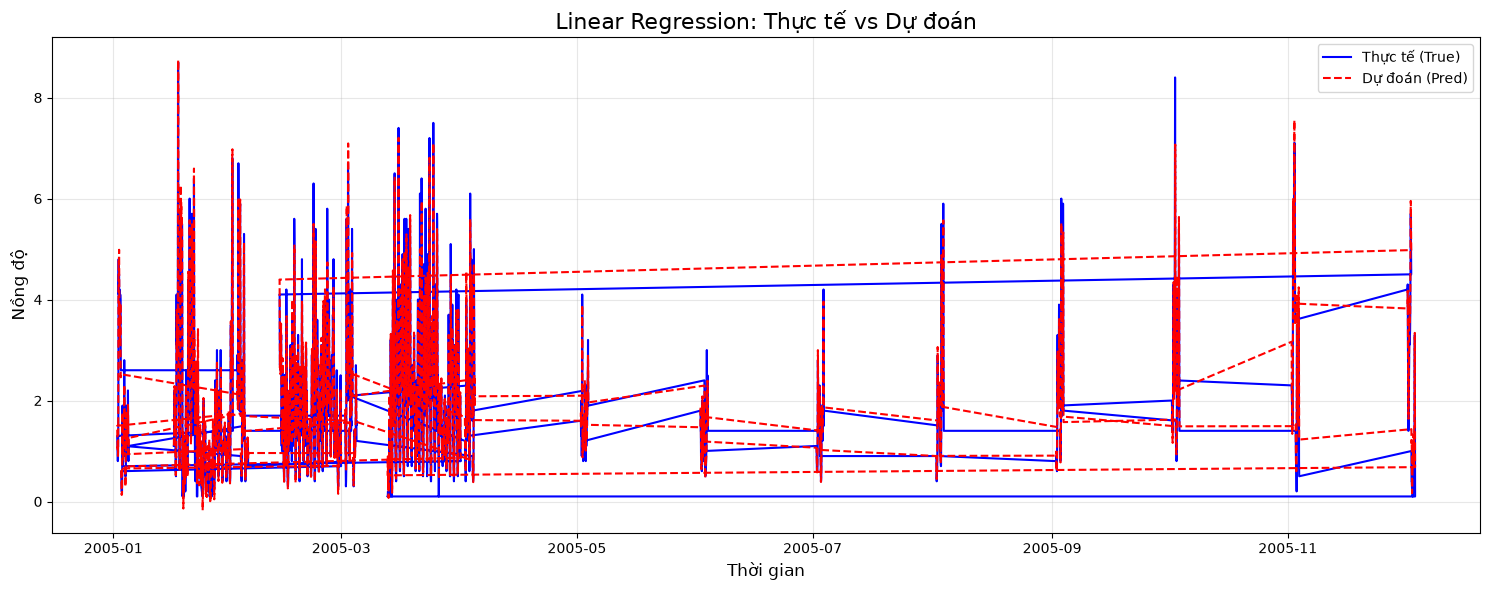

In [4]:
lr_model = train_linear_regression(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

metrics_lr = calculate_metrics(y_test, lr_preds, "Linear Regression")
plot_predictions(y_test.values, lr_preds, test_dates, 
                 "Linear Regression: Thực tế vs Dự đoán", 
                 "lr_predictions.png")

Baseline 2 - Random Forest

--- Kết quả cho Random Forest ---
MAE  (Sai số tuyệt đối trung bình) : 0.2859
RMSE (Sai số toàn phương trung bình): 0.4370
R2   (Hệ số xác định)             : 0.8999

Đã lưu đồ thị tại: ../reports/figures/rf_predictions.png


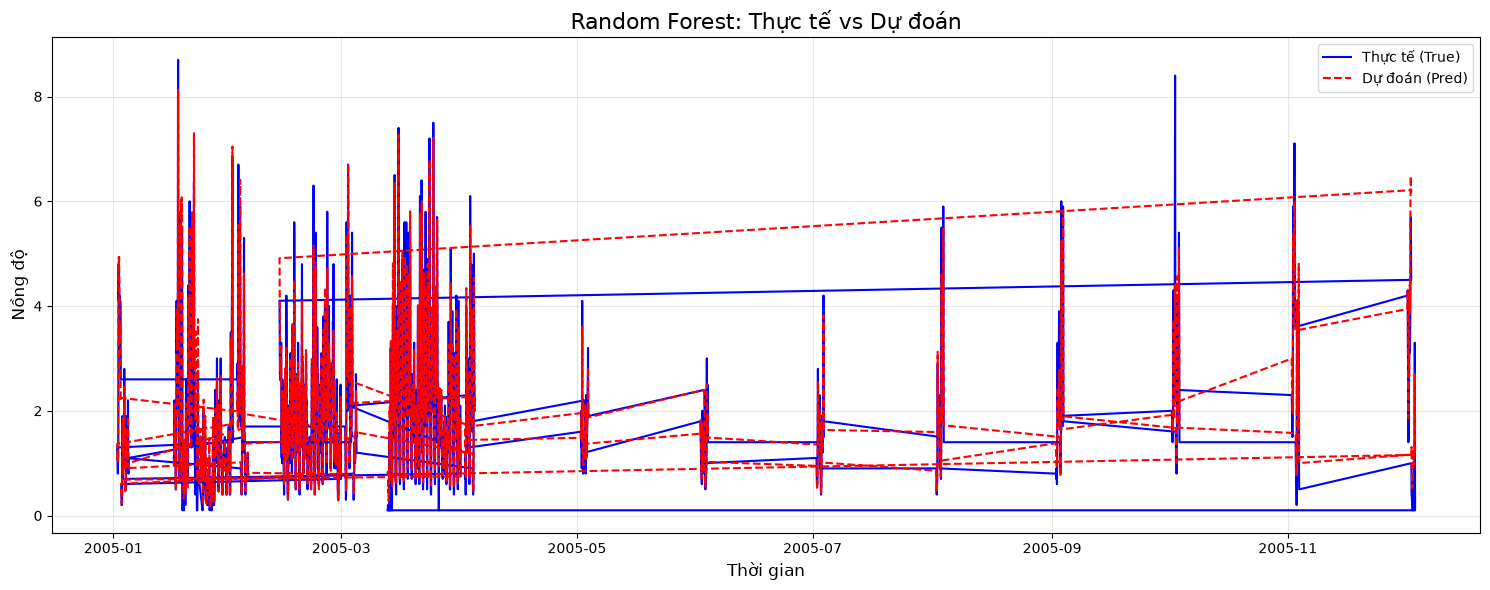

In [5]:
rf_model = train_random_forest(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

metrics_rf = calculate_metrics(y_test, rf_preds, "Random Forest")
plot_predictions(y_test.values, rf_preds, test_dates, 
                 "Random Forest: Thực tế vs Dự đoán", 
                 "rf_predictions.png")

Baseline 3 - ARIMA

Đang huấn luyện ARIMA với cấu hình order=(3, 1, 1)...
--- Kết quả cho ARIMA ---
MAE  (Sai số tuyệt đối trung bình) : 1.2701
RMSE (Sai số toàn phương trung bình): 1.5000
R2   (Hệ số xác định)             : -0.1795

Đã lưu đồ thị tại: ../reports/figures/arima_predictions.png


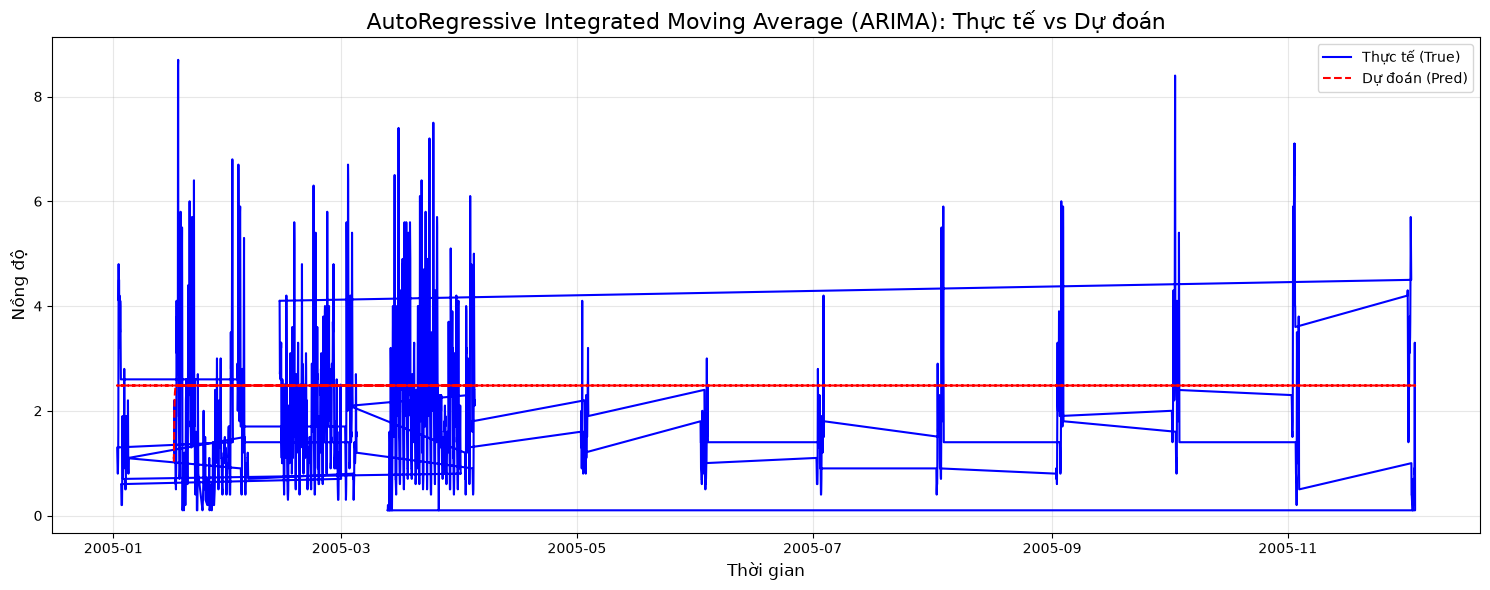

In [6]:
# ARIMA chỉ cần chuỗi y mục tiêu
arima_preds = train_predict_arima(y_train, y_test, order=(3, 1, 1))

metrics_arima = calculate_metrics(y_test, arima_preds, "ARIMA")
plot_predictions(y_test.values, arima_preds, test_dates, 
                 "AutoRegressive Integrated Moving Average (ARIMA): Thực tế vs Dự đoán", 
                 "arima_predictions.png")

Chạy mô hình Nâng cao - LSTM

Đang huấn luyện LSTM (Deep Learning)...
Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.8003 - val_loss: 0.8293
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8457 - val_loss: 0.7218
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6884 - val_loss: 0.7299
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6434 - val_loss: 0.8212
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6087 - val_loss: 0.5762
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5700 - val_loss: 0.5852
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5600 - val_loss: 0.5774
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5468 - val_loss: 0.5866
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- Kết quả cho LSTM Neural Network ---
MAE  (Sai số tuyệt đối trung bình) : 0.5428
RMSE (Sai số toàn phương trung bình): 0.7448
R2   (Hệ số xác định)             : 0.7100

Đã lưu đồ thị tại: ../reports/figures/lstm_predictions.png


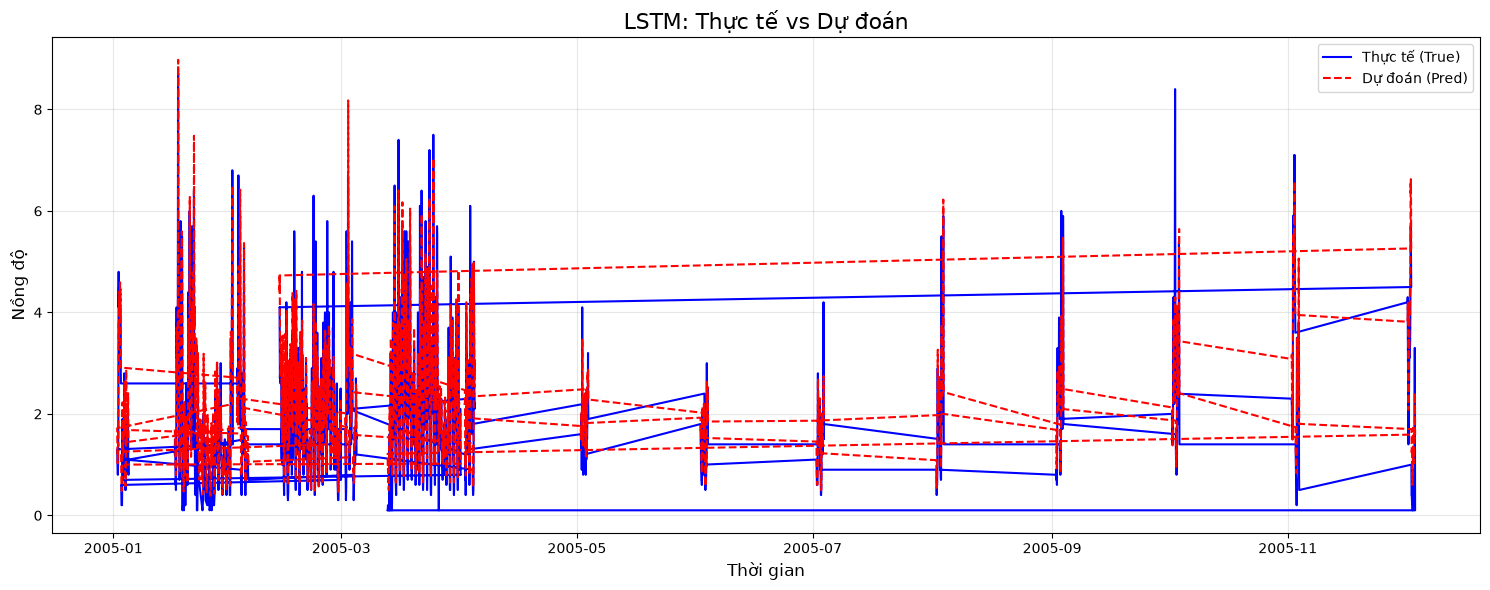

In [8]:
import numpy as np

def create_advanced_lstm_dataset(X, y, time_steps=6):
    """
    Biến đổi dữ liệu thành cấu trúc chuỗi thời gian thực sự cho LSTM.
    Nếu time_steps=6, mô hình sẽ dùng dữ liệu từ t-5 đến t để dự báo cho t+1.
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 6
X_train_lstm, y_train_lstm = create_advanced_lstm_dataset(X_train_scaled, y_train, time_steps=TIME_STEPS)
X_test_lstm, y_test_lstm = create_advanced_lstm_dataset(X_test_scaled, y_test, time_steps=TIME_STEPS)



y_test_adjusted = y_test_lstm
test_dates_adjusted = test_dates[TIME_STEPS:] 

lstm_model, lstm_preds = build_and_train_lstm(X_train_lstm, y_train_lstm, X_test_lstm, epochs=50)

metrics_lstm = calculate_metrics(y_test_adjusted, lstm_preds, "LSTM Neural Network")
plot_predictions(y_test_adjusted, lstm_preds, test_dates_adjusted , 
                 "LSTM: Thực tế vs Dự đoán", 
                 "lstm_predictions.png")

# Tổng hợp so sánh các model

In [9]:
# Tạo bảng so sánh
results_df = pd.DataFrame([metrics_lr, metrics_rf, metrics_arima, metrics_lstm], 
                          index=['Linear Regression', 'Random Forest', 'ARIMA', 'LSTM'])

print("=== BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH ===")
display(results_df.sort_values(by='MAE'))

=== BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH ===


,MAE,RMSE,R2
Linear Regression,0.265138,0.383090,0.923069
Random Forest,0.285911,0.437031,0.899879
LSTM,0.542769,0.744836,0.709952
ARIMA,1.270053,1.499998,-0.179451
